In [1]:
#########################################################################################################################
# Load required libraries 
#########################################################################################################################
import numpy as np
from matplotlib import pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, Exponentiation, ExpSineSquared, WhiteKernel, RBF, Matern
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact


In [7]:
#########################################################################################################################
# Define the GPR function
#########################################################################################################################
def GPR_Model(X, y, training_indices, LS_bounds=(1e-1, 25), nu=1.5, alpha=1e-10):
    """
    Fits a Gaussian Process Regressor on data and returns the mean and standard deviation of predictions
    :param X: 1D vector containing the x values of observed data (e.g. months)
    :param y: 1D vector containing the y values of observed data (e.g. steam flow)
    :param training_indices: The indices of observations to train on.
    :param well_number: The number of the well being modeled (for labeling purposes)
    :param color: The color for the plot of this well's data
    :return: mean_prediction, std_prediction
    """
    X_train, y_train = X[training_indices], y[training_indices]

    kernel = 1*Matern(length_scale_bounds=LS_bounds, nu=nu)
    gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=alpha)

    gaussian_process.fit(X_train, y_train)

    mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)

    optimized_kernel = gaussian_process.kernel_
    cov_matrix = compute_covariance_matrix(optimized_kernel, X_train)

    return mean_prediction, std_prediction, cov_matrix

In [3]:
#########################################################################################################################
# Define the covariance matrix function
#########################################################################################################################
def compute_covariance_matrix(kernel, X_train):
    """
    Computes the covariance matrix for the training points using the specified kernel.
    :param kernel: The kernel used in the Gaussian Process.
    :param X_train: The training data points.
    :return: Covariance matrix.
    """
    # Compute the covariance matrix
    K = kernel(X_train)
    K = K/K[0][0]
    return K

In [4]:
#########################################################################################################################
# Define the wells data
#########################################################################################################################

Well9 = {
    # Data for well 9
        'months': np.linspace(start=1, stop=12, num=12).reshape(-1, 1),
        'y': np.array([19.42, 19.94, 19.92, 19.96, 20.03, 20.13, 20.25, 20.42, 20.63, 20.9, 21.25, 21.76]),
        'training_indices': np.array([2, 5, 9]),
        'well_number': 9,
        'color': 'blue'
}

Well7 = {
    # Data for well 7
        'months': np.linspace(start=1, stop=12, num=12).reshape(-1, 1),
        'y': np.array([2.77, 2.74, 2.72, 2.71, 2.7, 2.69, 2.68, 2.67, 2.66, 2.66, 2.65, 2.65]),
        'training_indices': np.array([2, 5, 9]),
        'well_number': 7,
        'color': 'green'
}

Well3 = {
    # Data for well 3
        'months': np.linspace(start=1, stop=12, num=12).reshape(-1, 1),
        'y': np.array([26.64, 27, 27.57, 28.26, 29.1, 30.11, 31.31, 32.75, 34.4, 36.32, 38.59, 41.45]),
        'training_indices': np.array([2, 5, 9]),
        'well_number': 3,
        'color': 'red'
}

total_steam_flow = {
        # Data for the total steam flow
        'months': np.linspace(start=1, stop=12, num=12).reshape(-1, 1),
        'y': np.array([48.83, 49.68, 50.21, 50.93, 51.83, 52.93, 54.24, 55.84, 57.69, 59.88, 62.49, 65.86])
    }


In [8]:
#########################################################################################################################
# Run predictions for each of the wells
#########################################################################################################################

mean_pred_9, std_pred_9, cov_mat_9 = GPR_Model(Well9['months'],Well9['y'],Well9['training_indices'])
mean_pred_7, std_pred_7, cov_mat_7 = GPR_Model(Well7['months'],Well7['y'],Well7['training_indices'])
mean_pred_3, std_pred_3, cov_mat_3 = GPR_Model(Well3['months'],Well3['y'],Well3['training_indices'])

C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 25.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "
C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 25.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "
C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 25.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "


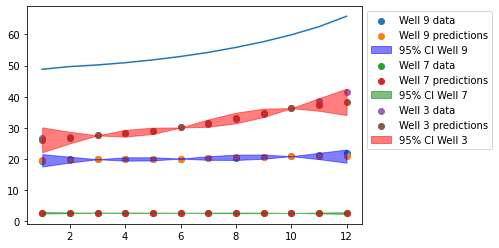

In [11]:
#########################################################################################################################
# Plot the results of these predictions
#########################################################################################################################

plt.scatter(Well9['months'], Well9['y'], label= "Well 9 data")
plt.scatter(Well9['months'], mean_pred_9, label= "Well 9 predictions")
plt.fill_between(
    Well9['months'].ravel(),
    mean_pred_9 - 2*std_pred_9,
    mean_pred_9 + 2*std_pred_9,
    alpha=0.5,
    color='blue',
    label="95% CI Well 9"
)

plt.scatter(Well7['months'], Well7['y'], label= "Well 7 data")
plt.scatter(Well7['months'], mean_pred_7, label= "Well 7 predictions")
plt.fill_between(
    Well7['months'].ravel(),
    mean_pred_7 - 2*std_pred_7,
    mean_pred_7 + 2*std_pred_7,
    alpha=0.5,
    color='green',
    label="95% CI Well 7"
)

plt.scatter(Well3['months'], Well3['y'], label= "Well 3 data")
plt.scatter(Well3['months'], mean_pred_3, label= "Well 3 predictions")
plt.fill_between(
    Well3['months'].ravel(),
    mean_pred_3 - 2*std_pred_3,
    mean_pred_3 + 2*std_pred_3,
    alpha=0.5,
    color='red',
    label="95% CI Well 3"
)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.plot(total_steam_flow['months'], total_steam_flow['y'])

C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "
C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "
C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "


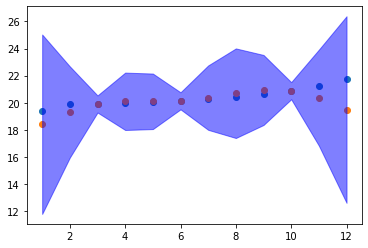

In [68]:
#########################################################################################################################
# Plot the results of these predictions
#########################################################################################################################
mean_pred_9, std_pred_9, cov_mat_9 = GPR_Model(Well9['months'],Well9['y'],Well9['training_indices'], alpha=1e-1)
mean_pred_7, std_pred_7, cov_mat_7 = GPR_Model(Well7['months'],Well7['y'],Well7['training_indices'])
mean_pred_3, std_pred_3, cov_mat_3 = GPR_Model(Well3['months'],Well3['y'],Well3['training_indices'])


plt.scatter(Well9['months'], Well9['y'], label= "Well 9 data")
plt.scatter(Well9['months'], mean_pred_9, label= "Well 9 predictions")
plt.fill_between(
    Well9['months'].ravel(),
    mean_pred_9 - 2*std_pred_9,
    mean_pred_9 + 2*std_pred_9,
    alpha=0.5,
    color='blue',
    label="95% CI Well 9"
)

# plt.scatter(Well7['months'], Well7['y'], label= "Well 7 data")
# plt.scatter(Well7['months'], mean_pred_7, label= "Well 7 predictions")
# plt.fill_between(
#     Well7['months'].ravel(),
#     mean_pred_7 - 2*std_pred_7,
#     mean_pred_7 + 2*std_pred_7,
#     alpha=0.5,
#     color='green',
#     label="95% CI Well 7"
# )

# plt.scatter(Well3['months'], Well3['y'], label= "Well 3 data")
# plt.scatter(Well3['months'], mean_pred_3, label= "Well 3 predictions")
# plt.fill_between(
#     Well3['months'].ravel(),
#     mean_pred_3 - 2*std_pred_3,
#     mean_pred_3 + 2*std_pred_3,
#     alpha=0.5,
#     color='red',
#     label="95% CI Well 3"
# )

# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.plot(total_steam_flow['months'], total_steam_flow['y'])

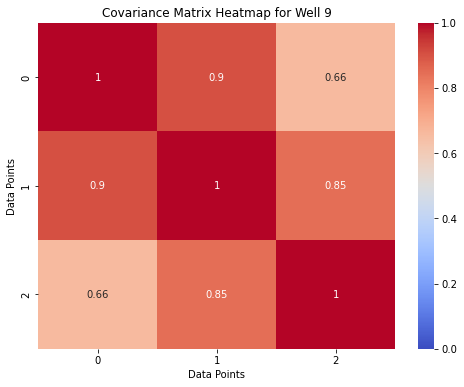

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(cov_mat_9, annot=True, cmap='coolwarm', vmin=0, vmax=1)

# Adding labels and title
plt.title('Covariance Matrix Heatmap for Well 9')
plt.xlabel('Data Points')
plt.ylabel('Data Points')

# Show the plot
plt.show()

In [ ]:
Notes:
    Adjust alpha parameter to fit better (Done)
    Find a way to determine length scale to particular problem (Done)
    See if variance between points can be increased (Done)
    Look into source code for kernel used
    Potentially scale data: new = (old-offset)/characterstic_length
        Offset should be mean of data and charcteristic_length is deviation

In [ ]:
Changes made:
    Now using Matern kernel. Gives wider confidence interval so better for uncertainty.
    Input lemgth scale bounds rather than length scale (correlation effects are clearly evident)
    Made alpha an input and thus gives error for measurements.

In [13]:
Writing the custom kernel:
    Redefine the operation kernel:
        (Notes for me)
        example, ytotal = y1+y2+y3+...+yn (i.e. total steam is the sum of indivdual steam across the wells)
        Need to fit with the constraint
        Fit them simulatenously (make them uncorrelated)
    step 1:
        take two wells and fit them simulatenously 
        covariance matrix will be the wells and the inside will be the datapoints.
        

The general idea is:
    1) Create a covariance matrix where data points within wells are correlated but uncorrelated between wells.
    2) Fit a GPR model to the sum of indivdual well kernels (i.e. fit a GPR model on total steam flow) to ensure
    the constraint of steam flow across all wells must sum to total steam flow.
    3) Use this fitted GPR model (for ytotal) to act as a conditioner for other wells.
    4) Simultaneously fit a GPR model to the individual wells to ensure conditioning works properly.

If process is done correctly then easily can take a time point and extract an individual steam production value for the
wells and hence be able to determine mass flow by using the knowledge (as well as dryness knowledge).

Potential issues:
    Need to deal with the ON/OFF well problem (can probs treat off wells as 0 steam flow in order to make everything consistent)
    GPR will not work with 1 data point. 2 data points seem to not be great.
    Extrapolation becomes terrible (due to no points to correlate itself with) so extrapolation intervals may be ok for a 
    short period but quickly can become useless.

Questions?
How do we deal with cases where a well is on and exists yet has no data/1 data point?
How can we determine what the correlation between training data points should be?
How wide/narrow should the uncertainty interval be so that we are not creating an interval that is too wide yet too narrow
(i.e. too uncertain vs too certain)

SyntaxError: invalid syntax (Temp/ipykernel_31368/1849909494.py, line 1)